In [ ]:
# Cargar de la base de datosdesde el drive.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd


df = pd.read_csv("/content/drive/MyDrive/talentotech2/Normales_Climatológicas_de_Colombia_20260420.csv")
df

,PERIODO,PARÁMETRO,CÓDIGO,CATEGORIA,ESTACIÓN,MUNICIPIO,DEPARTAMENTO,AO,ALTITUD (m),LONGITUD,...,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,1961-1990,PRECIPITACIÓN,"48,015,050",SP,Aeropuerto Vasquez Cobo,Leticia,Amazonas,11,84,-69.94,...,363.7,278.2,201.8,165.2,163.1,225.9,284.6,284.5,290.1,"3,275.3"
1,1961-1990,PRECIPITACIÓN,"26,180,160",PM,Abejorral,Abejorral,Antioquia,1,"2,450",-75.43,...,247.6,264.9,157.9,128.3,194.9,269.3,304.3,260.7,176.9,"2,408.3"
2,1961-1990,PRECIPITACIÓN,"26,180,090",PG,El Buey,Abejorral,Antioquia,1,"2,110",-75.45,...,192.9,236.2,172.8,128.7,174.2,210.2,276.2,223,96.4,"1,957.8"
3,1961-1990,PRECIPITACIÓN,"27,010,850",PM,Amalfi,Amalfi,Antioquia,1,"1,530",-75.08,...,392.9,432.6,323.2,314.9,357.2,434.9,544.3,344.7,154.8,"3,747.7"
4,1961-1990,PRECIPITACIÓN,"27,010,890",PM,Cueva Santa,Amalfi,Antioquia,1,"1,550",-75.04,...,346,333.7,288.6,310.5,318.6,319.3,372.9,267.3,119.5,"3,093.8"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14711,1991-2020,BRILLO SOLAR,"26,085,130",CO,La Buitrera,Yumbo,Valle del Cauca,9,"1,500",-76.57,...,2.8,2.7,2.9,4,4.7,3.6,3.1,2.5,2.6,3.3
14712,1991-2020,BRILLO SOLAR,"42,075,010",CP,Mitú,Mitú,Vaupés,3,180,-70.24,...,3.5,3.5,3.5,3.6,4.7,5,5,4.3,4.3,4.1
14713,1991-2020,BRILLO SOLAR,"33,055,010",CO,Cumaribo 2,Cumaribo,Vichada,3,167,-69.80,...,4.4,4.1,3.8,4.2,4.4,4.9,5.5,6,7.3,5.4
14714,1991-2020,BRILLO SOLAR,"34,015,010",CP,Las Gaviotas,Cumaribo,Vichada,3,171,-70.93,...,4.2,3.6,3.5,3.7,4.1,4.9,5.3,5.6,6.7,5.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Crear una copia de la base de datos:
df_copia = df.copy()

In [ ]:
# Resumen estructural del DataFrame.
df_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14716 entries, 0 to 14715
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PERIODO       14716 non-null  object 
 1   PARÁMETRO     14716 non-null  object 
 2   CÓDIGO        14716 non-null  object 
 3   CATEGORIA     14716 non-null  object 
 4   ESTACIÓN      14716 non-null  object 
 5   MUNICIPIO     14716 non-null  object 
 6   DEPARTAMENTO  14716 non-null  object 
 7   AO            14716 non-null  int64  
 8   ALTITUD (m)   14716 non-null  object 
 9   LONGITUD      14716 non-null  float64
 10  LATITUD       14716 non-null  float64
 11  ENE           14716 non-null  object 
 12  FEB           14716 non-null  float64
 13  MAR           14716 non-null  object 
 14  ABR           14716 non-null  object 
 15  MAY           14716 non-null  object 
 16  JUN           14716 non-null  object 
 17  JUL           14716 non-null  object 
 18  AGO           14716 non-nu

In [ ]:
# Validar valores nulos
df_copia.isnull()

,PERIODO,PARÁMETRO,CÓDIGO,CATEGORIA,ESTACIÓN,MUNICIPIO,DEPARTAMENTO,AO,ALTITUD (m),LONGITUD,...,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14711,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14712,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14713,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14714,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Devuelve la cantidad de nulos que hay en todo el dataframe

df_copia.isnull().sum()

,0
PERIODO,0
PARÁMETRO,0
CÓDIGO,0
CATEGORIA,0
ESTACIÓN,0
MUNICIPIO,0
DEPARTAMENTO,0
AO,0
ALTITUD (m),0
LONGITUD,0


In [ ]:
df_copia["CATEGORIA"] = df_copia["CATEGORIA"].replace({
    'SP': 'sipnotica principal', #  Estación completa que mide muchas variables (temperatura, presión, viento, humedad, etc.)
    'PM': 'pluviometria', # Solo mide precipitación (lluvia).
    'PG': 'pluviografica', # Registra la lluvia de forma continua (intensidad y duración), no solo el total.
    'CO': 'climatologia ordinal', # Mide variables básicas como temperatura y precipitación, con observaciones manuales.
    'CP':"climatologia principal", # Más completa que la ordinaria; incluye más variables y mayor control de calidad.
    'LM': 'Limnimetria', # Mide niveles de agua en ríos o cuerpos hídricos.
    'AM': 'automatica', # Estación automática que registra datos en tiempo real sin intervención manual.
    'ME': 'meteorologia especial', # Estación con fines específicos (investigación, aeropuertos, etc.)
    'SS': 'sipnotica secundaria', # Similar a la sinóptica principal pero con menor frecuencia o menos variables.
    'LG': 'limnigrafica', # Registra continuamente niveles de agua (como la limnimétrica pero con gráfico/registro continuo).
})

# Volvemos a mostrar los valores únicos para verificar los cambios
df_copia["CATEGORIA"].unique()


array(['sipnotica principal', 'pluviometria', 'pluviografica',
       'climatologia ordinal', 'climatologia principal', 'Limnimetria',
       'automatica', 'meteorologia especial', 'sipnotica secundaria',
       'limnigrafica'], dtype=object)

In [ ]:
# Eliminar las columnas "CODIGO y AO por ser relevantes para el analisis"

#df_copia.drop(columns=["CÓDIGO", "AO"], inplace=True)
#df_copia

In [ ]:
# Se Renombran las siguientes columnas para quitar tildes

df_copia = df_copia.rename(columns={'PARÁMETRO': 'PARAMETRO'})
df_copia = df_copia.rename(columns={'ESTACIÓN': 'ESTACION'})
df_copia

,PERIODO,PARAMETRO,CÓDIGO,CATEGORIA,ESTACION,MUNICIPIO,DEPARTAMENTO,AO,ALTITUD (m),LONGITUD,...,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,1961-1990,PRECIPITACIÓN,"48,015,050",sipnotica principal,Aeropuerto Vasquez Cobo,Leticia,Amazonas,11,84,-69.94,...,363.7,278.2,201.8,165.2,163.1,225.9,284.6,284.5,290.1,"3,275.3"
1,1961-1990,PRECIPITACIÓN,"26,180,160",pluviometria,Abejorral,Abejorral,Antioquia,1,"2,450",-75.43,...,247.6,264.9,157.9,128.3,194.9,269.3,304.3,260.7,176.9,"2,408.3"
2,1961-1990,PRECIPITACIÓN,"26,180,090",pluviografica,El Buey,Abejorral,Antioquia,1,"2,110",-75.45,...,192.9,236.2,172.8,128.7,174.2,210.2,276.2,223,96.4,"1,957.8"
3,1961-1990,PRECIPITACIÓN,"27,010,850",pluviometria,Amalfi,Amalfi,Antioquia,1,"1,530",-75.08,...,392.9,432.6,323.2,314.9,357.2,434.9,544.3,344.7,154.8,"3,747.7"
4,1961-1990,PRECIPITACIÓN,"27,010,890",pluviometria,Cueva Santa,Amalfi,Antioquia,1,"1,550",-75.04,...,346,333.7,288.6,310.5,318.6,319.3,372.9,267.3,119.5,"3,093.8"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14711,1991-2020,BRILLO SOLAR,"26,085,130",climatologia ordinal,La Buitrera,Yumbo,Valle del Cauca,9,"1,500",-76.57,...,2.8,2.7,2.9,4,4.7,3.6,3.1,2.5,2.6,3.3
14712,1991-2020,BRILLO SOLAR,"42,075,010",climatologia principal,Mitú,Mitú,Vaupés,3,180,-70.24,...,3.5,3.5,3.5,3.6,4.7,5,5,4.3,4.3,4.1
14713,1991-2020,BRILLO SOLAR,"33,055,010",climatologia ordinal,Cumaribo 2,Cumaribo,Vichada,3,167,-69.80,...,4.4,4.1,3.8,4.2,4.4,4.9,5.5,6,7.3,5.4
14714,1991-2020,BRILLO SOLAR,"34,015,010",climatologia principal,Las Gaviotas,Cumaribo,Vichada,3,171,-70.93,...,4.2,3.6,3.5,3.7,4.1,4.9,5.3,5.6,6.7,5.1


In [ ]:
# Identificar cada valor único que hay en la columna PERIODO para identificar los 4  periodos de 29 sños cada uno .

df_copia["PERIODO"].unique()


array(['1961-1990', '1971-2000', '1981-2010', '1991-2020'], dtype=object)

In [ ]:
# Se identifica cada valor único que hay en la columna PARAMETRO.

df_copia["PARAMETRO"].unique()


array(['PRECIPITACIÓN', 'No. DE DIAS CON LLUVIA', 'TEMPERATURA MÁXIMA',
       'TEMPERATURA MEDIA', 'TEMPERATURA MÍNIMA', 'BRILLO SOLAR'],
      dtype=object)

In [ ]:
# Identificar cada valor único que hay en la columna CATEGORIA.

df_copia["CATEGORIA"].unique()


array(['sipnotica principal', 'pluviometria', 'pluviografica',
       'climatologia ordinal', 'climatologia principal', 'Limnimetria',
       'automatica', 'meteorologia especial', 'sipnotica secundaria',
       'limnigrafica'], dtype=object)

In [ ]:
# Identificar cada valor único que hay en la columna MUNICIPIO.

df_copia["MUNICIPIO"].unique()


array(['Leticia', 'Abejorral', 'Amalfi', 'Andes', 'Angostura', 'Anzá',
       'Arboletes', 'Barbosa', 'Bello', 'Belmira', 'Betania', 'Briceño',
       'Cáceres', 'Caicedo', 'Caldas', 'Campamento', 'Caracolí',
       'Carmen de Viboral', 'Carolina', 'Caucasia', 'Chigorodó',
       'Cocorná', 'Concepción', 'Concordia', 'Don Matías', 'Entrerrios',
       'Frontino', 'Giraldo', 'Girardota', 'Gómez Plata', 'Granada',
       'Guarne', 'Guatapé', 'Heliconia', 'Jardín', 'Jericó', 'La Unión',
       'Liborina', 'Marinilla', 'Medellín', 'Montebello', 'Nechí',
       'Peque', 'Pueblorrico', 'Puerto Berrío', 'Puerto Nare', 'Remedios',
       'Retiro', 'Rionegro', 'Salgar', 'San Andrés', 'San Carlos',
       'San José de La Montaña', 'San Juan de Urabá', 'San Pedro',
       'San Rafael', 'San Roque', 'San Vicente', 'Santa Rosa de Osos',
       'Santo Domingo', 'Santuario', 'Sonsón', 'Titiribí', 'Toledo',
       'Turbo', 'Urrao', 'Vegachí', 'Venecia', 'Vigia del Fuerte',
       'Yarumal', 'Zaragoza'

In [ ]:
# Limpiar espacios en blanco se han identificado varias inconsistencias en los nombres de los municipios. Para mejorar la calidad de los datos
df_copia['MUNICIPIO'] = df_copia['MUNICIPIO'].str.strip()

# Estandarizar los valores de la columna 'MUNICIPIO'
df_copia['MUNICIPIO'] = df_copia['MUNICIPIO'].replace({
    'Puerto Santander (Araracuara)': 'Puerto Santander',
    'San Andrés De Sotavento': 'San Andrés de Sotavento',
    'El Cantón Del San Pablo (Managrú)': 'El Cantón del San Pablo',
    'Armenia (Quindío)': 'Armenia',
    'Belén De Los Andaquíes': 'Belén de los Andaquíes',
    'Juan De Acosta': 'Juan de Acosta',
    'Paz De Ariporo': 'Paz de Ariporo',
    'Valle De San Juan': 'Valle de San Juan'
})

# Mostrar los valores únicos para verificar los cambios
df_copia['MUNICIPIO'].unique()

array(['Leticia', 'Abejorral', 'Amalfi', 'Andes', 'Angostura', 'Anzá',
       'Arboletes', 'Barbosa', 'Bello', 'Belmira', 'Betania', 'Briceño',
       'Cáceres', 'Caicedo', 'Caldas', 'Campamento', 'Caracolí',
       'Carmen de Viboral', 'Carolina', 'Caucasia', 'Chigorodó',
       'Cocorná', 'Concepción', 'Concordia', 'Don Matías', 'Entrerrios',
       'Frontino', 'Giraldo', 'Girardota', 'Gómez Plata', 'Granada',
       'Guarne', 'Guatapé', 'Heliconia', 'Jardín', 'Jericó', 'La Unión',
       'Liborina', 'Marinilla', 'Medellín', 'Montebello', 'Nechí',
       'Peque', 'Pueblorrico', 'Puerto Berrío', 'Puerto Nare', 'Remedios',
       'Retiro', 'Rionegro', 'Salgar', 'San Andrés', 'San Carlos',
       'San José de La Montaña', 'San Juan de Urabá', 'San Pedro',
       'San Rafael', 'San Roque', 'San Vicente', 'Santa Rosa de Osos',
       'Santo Domingo', 'Santuario', 'Sonsón', 'Titiribí', 'Toledo',
       'Turbo', 'Urrao', 'Vegachí', 'Venecia', 'Vigia del Fuerte',
       'Yarumal', 'Zaragoza'

In [ ]:
# Identificar cada valor único que hay en la columna DEPARTAMENTO.

df_copia["DEPARTAMENTO"].unique()


array(['Amazonas', 'Antioquia', 'Arauca',
       'Archipiélago de San Andres, Providencia y Santa Catalina',
       'Atlántico', 'Bolívar', 'Boyacá', 'Caldas', 'Caquetá', 'Casanare',
       'Cauca', 'Cesar', 'Chocó', 'Córdoba', 'Cundinamarca', 'Guainía',
       'Huila', 'La Guajira', 'Magdalena', 'Meta', 'Nariño',
       'Norte de Santander', 'Putumayo', 'Quindío', 'RIsaralda',
       'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle del Cauca',
       'Valle Del Cauca', 'Vichada', 'Atlantico', 'Guaviare', 'Vaupés',
       'Choco', 'Cordoba', 'Caqueta'], dtype=object)

In [ ]:
# Estandarizamos los valores de la columna "DEPARTAMENTO" e han identificado inconsistencias en los nombres de los departamentos debido a mayúsculas, minúsculas y tildes
df_copia["DEPARTAMENTO"] = df_copia["DEPARTAMENTO"].replace({
    'RIsaralda': 'Risaralda',
    'Valle Del Cauca': 'Valle del Cauca',
    'Atlantico': 'Atlántico',
    'Choco': 'Chocó',
    'Cordoba': 'Córdoba',
    'Caqueta': 'Caquetá'
})

# Volvemos a mostrar los valores únicos para verificar los cambios
df_copia["DEPARTAMENTO"].unique()

array(['Amazonas', 'Antioquia', 'Arauca',
       'Archipiélago de San Andres, Providencia y Santa Catalina',
       'Atlántico', 'Bolívar', 'Boyacá', 'Caldas', 'Caquetá', 'Casanare',
       'Cauca', 'Cesar', 'Chocó', 'Córdoba', 'Cundinamarca', 'Guainía',
       'Huila', 'La Guajira', 'Magdalena', 'Meta', 'Nariño',
       'Norte de Santander', 'Putumayo', 'Quindío', 'Risaralda',
       'Santander', 'Sucre', 'Tolima', 'Valle del Cauca', 'Vichada',
       'Guaviare', 'Vaupés'], dtype=object)

In [ ]:
# Las siguientes columnas de meses el tipo de dato es string, sin embargo son números.
# ENE           14716 non-null  object
# MAR           14716 non-null  object
# ABR           14716 non-null  object
# MAY           14716 non-null  object
# JUN           14716 non-null  object
# JUL           14716 non-null  object
# AGO           14716 non-null  object
# SEP           14716 non-null  object
# OCT           14716 non-null  object
# NOV           14716 non-null  object
# DIC           14716 non-null  object
# ANUAL         14716 non-null  object

columns_to_convert = [
    "ENE", "MAR", "ABR", "MAY", "JUN", "JUL", "AGO", "SEP", "OCT", "NOV", "DIC", "ANUAL", "ALTITUD (m)"
]

for col in columns_to_convert:
    df_copia[col] = df_copia[col].astype(str).str.replace(',', '', regex=False).astype("float64")

df_copia

,PERIODO,PARAMETRO,CÓDIGO,CATEGORIA,ESTACION,MUNICIPIO,DEPARTAMENTO,AO,ALTITUD (m),LONGITUD,...,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,1961-1990,PRECIPITACIÓN,"48,015,050",sipnotica principal,Aeropuerto Vasquez Cobo,Leticia,Amazonas,11,84.0,-69.94,...,363.7,278.2,201.8,165.2,163.1,225.9,284.6,284.5,290.1,3275.3
1,1961-1990,PRECIPITACIÓN,"26,180,160",pluviometria,Abejorral,Abejorral,Antioquia,1,2450.0,-75.43,...,247.6,264.9,157.9,128.3,194.9,269.3,304.3,260.7,176.9,2408.3
2,1961-1990,PRECIPITACIÓN,"26,180,090",pluviografica,El Buey,Abejorral,Antioquia,1,2110.0,-75.45,...,192.9,236.2,172.8,128.7,174.2,210.2,276.2,223.0,96.4,1957.8
3,1961-1990,PRECIPITACIÓN,"27,010,850",pluviometria,Amalfi,Amalfi,Antioquia,1,1530.0,-75.08,...,392.9,432.6,323.2,314.9,357.2,434.9,544.3,344.7,154.8,3747.7
4,1961-1990,PRECIPITACIÓN,"27,010,890",pluviometria,Cueva Santa,Amalfi,Antioquia,1,1550.0,-75.04,...,346.0,333.7,288.6,310.5,318.6,319.3,372.9,267.3,119.5,3093.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14711,1991-2020,BRILLO SOLAR,"26,085,130",climatologia ordinal,La Buitrera,Yumbo,Valle del Cauca,9,1500.0,-76.57,...,2.8,2.7,2.9,4.0,4.7,3.6,3.1,2.5,2.6,3.3
14712,1991-2020,BRILLO SOLAR,"42,075,010",climatologia principal,Mitú,Mitú,Vaupés,3,180.0,-70.24,...,3.5,3.5,3.5,3.6,4.7,5.0,5.0,4.3,4.3,4.1
14713,1991-2020,BRILLO SOLAR,"33,055,010",climatologia ordinal,Cumaribo 2,Cumaribo,Vichada,3,167.0,-69.80,...,4.4,4.1,3.8,4.2,4.4,4.9,5.5,6.0,7.3,5.4
14714,1991-2020,BRILLO SOLAR,"34,015,010",climatologia principal,Las Gaviotas,Cumaribo,Vichada,3,171.0,-70.93,...,4.2,3.6,3.5,3.7,4.1,4.9,5.3,5.6,6.7,5.1


In [ ]:
# El tipo de datos para todas las columnas de los meses es float y no object, como estaba antes.
df_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14716 entries, 0 to 14715
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PERIODO       14716 non-null  object 
 1   PARAMETRO     14716 non-null  object 
 2   CÓDIGO        14716 non-null  object 
 3   CATEGORIA     14716 non-null  object 
 4   ESTACION      14716 non-null  object 
 5   MUNICIPIO     14716 non-null  object 
 6   DEPARTAMENTO  14716 non-null  object 
 7   AO            14716 non-null  int64  
 8   ALTITUD (m)   14716 non-null  float64
 9   LONGITUD      14716 non-null  float64
 10  LATITUD       14716 non-null  float64
 11  ENE           14716 non-null  float64
 12  FEB           14716 non-null  float64
 13  MAR           14716 non-null  float64
 14  ABR           14716 non-null  float64
 15  MAY           14716 non-null  float64
 16  JUN           14716 non-null  float64
 17  JUL           14716 non-null  float64
 18  AGO           14716 non-nu

In [ ]:
# El tipo de datos para todas las columnas de los meses es float y no object, como estaba antes.
df_copia[["PERIODO","PARAMETRO", "ENE"]]

,PERIODO,PARAMETRO,ENE
0,1961-1990,PRECIPITACIÓN,348.7
1,1961-1990,PRECIPITACIÓN,105.1
2,1961-1990,PRECIPITACIÓN,61.7
3,1961-1990,PRECIPITACIÓN,116.7
4,1961-1990,PRECIPITACIÓN,75.6
...,...,...,...
14711,1991-2020,BRILLO SOLAR,3.6
14712,1991-2020,BRILLO SOLAR,4.4
14713,1991-2020,BRILLO SOLAR,7.8
14714,1991-2020,BRILLO SOLAR,7.8


In [ ]:
df_copia["PARAMETRO"].value_counts()

,count
PARAMETRO,
No. DE DIAS CON LLUVIA,5990
PRECIPITACIÓN,5458
TEMPERATURA MÍNIMA,1092
TEMPERATURA MEDIA,993
TEMPERATURA MÁXIMA,932
BRILLO SOLAR,251


In [ ]:
df_copia["PERIODO"].value_counts()

,count
PERIODO,
1991-2020,4595
1981-2010,4542
1971-2000,3673
1961-1990,1906


In [ ]:
# Para comprender las distribuciones básicas y los rangos de las columnas numéricas especificadas, calcularemos y mostraremos sus estadísticas descriptivas.

numerical_columns = [
    "ENE", "FEB", "MAR", "ABR", "MAY", "JUN", "JUL", "AGO", "SEP", "OCT", "NOV", "DIC", "ANUAL",
    "ALTITUD (m)", "LONGITUD", "LATITUD"
]

df_copia[numerical_columns].describe()

NameError: name 'df_copia' is not defined

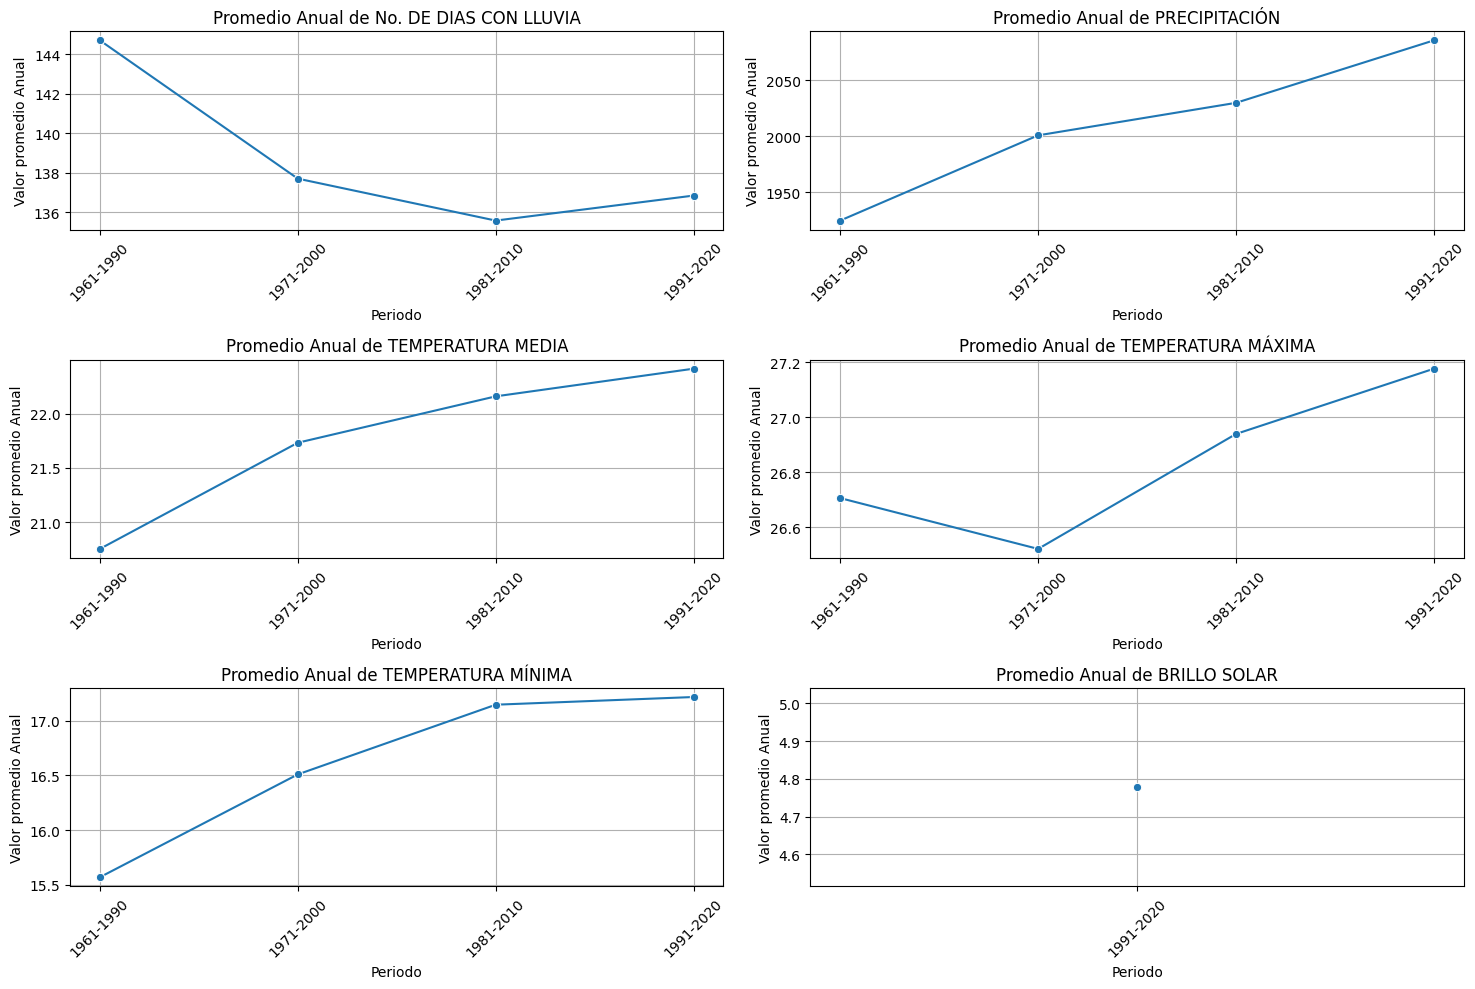

In [ ]:
# Para analizar los parámetros promedio anuales, primero se agrupan los datos por "PERIODO" y "PARAMETRO", calcularemos la media de la columna "ANUAL" y luego se restable el índice para preparar los datos para su visualización. Posteriormente, iteraremos a través de cada parámetro único para generar gráficos de líneas que muestren la tendencia de los promedios anuales a lo largo de los diferentes periodos, garantizando la claridad mediante el uso de títulos y etiquetas.

df_promedio_anual = df_copia.groupby(["PERIODO", "PARAMETRO"])["ANUAL"].mean().reset_index()

parametros_unicos = df_promedio_anual["PARAMETRO"].unique()

plt.figure(figsize=(15, 10))

for i, param in enumerate(parametros_unicos):

    datos_param = df_promedio_anual[df_promedio_anual["PARAMETRO"] == param]

    plt.subplot(3, 2, i + 1)
    sns.lineplot(data=datos_param, x="PERIODO", y="ANUAL", marker="o")
    plt.title(f"Promedio Anual de {param}")
    plt.xlabel("Periodo")
    plt.ylabel("Valor promedio Anual")
    plt.xticks(rotation=45)
    plt.grid(True)

plt.tight_layout()
plt.show()

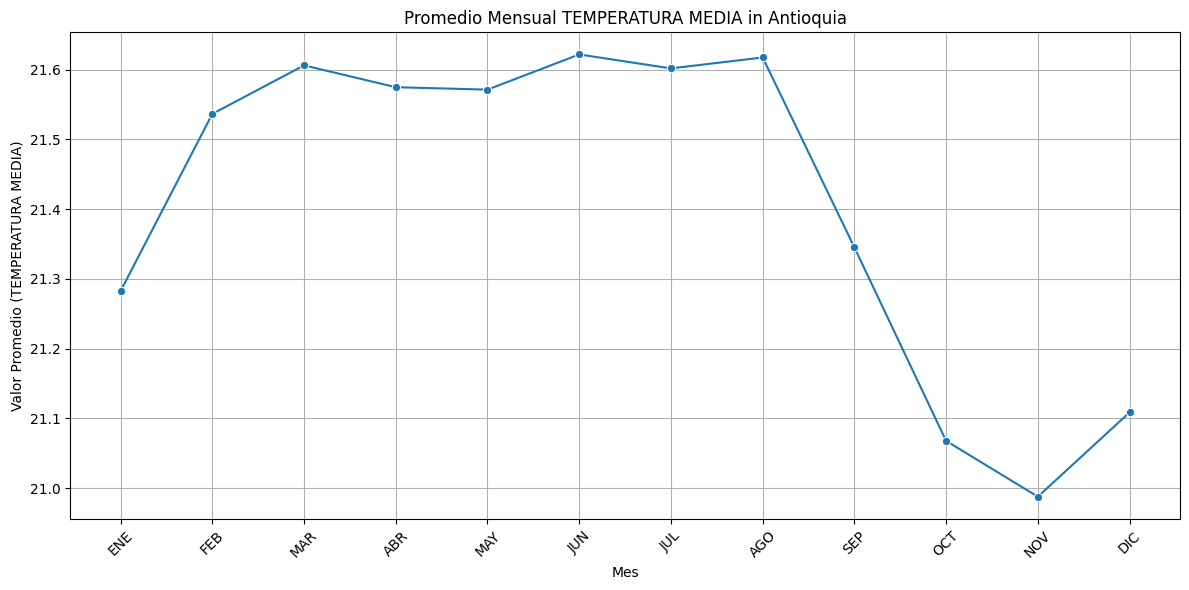

In [ ]:
# Para analizar los patrones estacionales, se selecciona un departamento y un parámetro específico, posteriormente se filtraran los datos en consecuencia, y extrae los valores mensuales para luego calcular el promedio y visualizar usando un gráfico lineal.

departamento_sel = "Antioquia"
parametro_obj = "TEMPERATURA MEDIA"

# Filtra el DataFrame para el departamento y parámetro objetivo
df_filtro_estacion = df_copia[
    (df_copia["DEPARTAMENTO"] == departamento_sel) &
    (df_copia["PARAMETRO"] == parametro_obj)
]

# Definir columnas mensuales
columnas_mes = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']

# Calcula la media del mes
valor_mes_media = df_filtro_estacion[columnas_mes].mean()

# Crear un DataFrame para graficar
df_plot_seasonal = pd.DataFrame({
    "Mes": columnas_mes,
    "Valor_Promedio": valor_mes_media.values
})

# Crea un grafico de lineas
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot_seasonal, x="Mes", y="Valor_Promedio", marker="o")
plt.title(f"Promedio Mensual {parametro_obj} in {departamento_sel}")
plt.xlabel("Mes")
plt.ylabel(f"Valor Promedio ({parametro_obj})")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Filtrar el DataFrame para incluir solo las filas donde el 'PARAMETRO' sea 'PRECIPITACIÓN'.
df_precipitacion = df_copia[df_copia['PARAMETRO'] == 'PRECIPITACIÓN'].copy()
df_precipitacion.head()

,PERIODO,PARAMETRO,CÓDIGO,CATEGORIA,ESTACION,MUNICIPIO,DEPARTAMENTO,AO,ALTITUD (m),LONGITUD,...,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,1961-1990,PRECIPITACIÓN,"48,015,050",sipnotica principal,Aeropuerto Vasquez Cobo,Leticia,Amazonas,11,84.0,-69.94,...,363.7,278.2,201.8,165.2,163.1,225.9,284.6,284.5,290.1,3275.3
1,1961-1990,PRECIPITACIÓN,"26,180,160",pluviometria,Abejorral,Abejorral,Antioquia,1,2450.0,-75.43,...,247.6,264.9,157.9,128.3,194.9,269.3,304.3,260.7,176.9,2408.3
2,1961-1990,PRECIPITACIÓN,"26,180,090",pluviografica,El Buey,Abejorral,Antioquia,1,2110.0,-75.45,...,192.9,236.2,172.8,128.7,174.2,210.2,276.2,223.0,96.4,1957.8
3,1961-1990,PRECIPITACIÓN,"27,010,850",pluviometria,Amalfi,Amalfi,Antioquia,1,1530.0,-75.08,...,392.9,432.6,323.2,314.9,357.2,434.9,544.3,344.7,154.8,3747.7
4,1961-1990,PRECIPITACIÓN,"27,010,890",pluviometria,Cueva Santa,Amalfi,Antioquia,1,1550.0,-75.04,...,346.0,333.7,288.6,310.5,318.6,319.3,372.9,267.3,119.5,3093.8


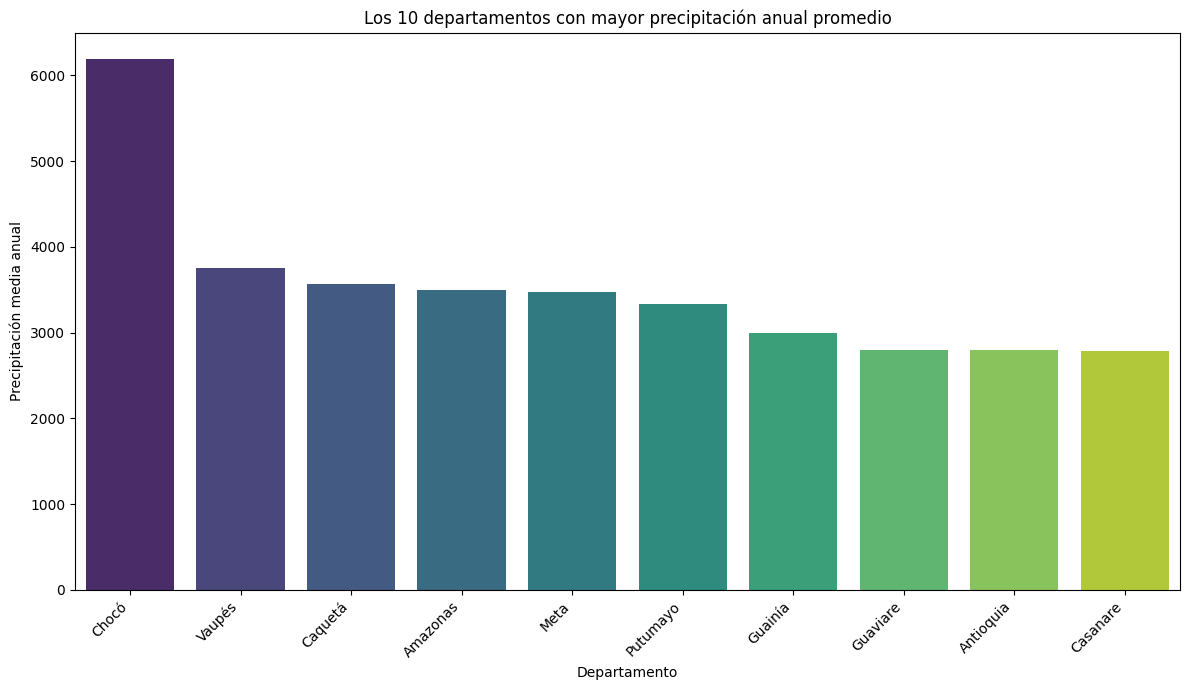

In [ ]:
# Agrupar por 'DEPARTAMENTO' y 'PERIODO', y calcular la precipitación anual promedio
df_departamento_precipitacion = df_precipitacion.groupby(["DEPARTAMENTO", "PERIODO"])["ANUAL"].mean().reset_index()

# Calcular la precipitación anual promedio por departamento en todos los períodos
df_mayor_precipitacion_prom = df_departamento_precipitacion.groupby("DEPARTAMENTO")["ANUAL"].mean().reset_index()

# Identificar los 10 departamentos con la mayor precipitación anual promedio
top_10_departmentos = df_mayor_precipitacion_prom.nlargest(10, "ANUAL")

# Visualizar los resultados
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_departmentos, x="DEPARTAMENTO", y="ANUAL", hue="DEPARTAMENTO", palette="viridis", legend=False)
plt.title("Los 10 departamentos con mayor precipitación anual promedio")
plt.xlabel("Departamento")
plt.ylabel("Precipitación media anual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# primero se filtra el DataFrame para incluir solo las filas donde el "PARÁMETRO" sea "PRECIPICIÓN".
df_precipitacion = df_copia[df_copia['PARAMETRO'] == 'PRECIPITACIÓN'].copy()
df_precipitacion.head()

,PERIODO,PARAMETRO,CÓDIGO,CATEGORIA,ESTACION,MUNICIPIO,DEPARTAMENTO,AO,ALTITUD (m),LONGITUD,...,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,1961-1990,PRECIPITACIÓN,"48,015,050",sipnotica principal,Aeropuerto Vasquez Cobo,Leticia,Amazonas,11,84.0,-69.94,...,363.7,278.2,201.8,165.2,163.1,225.9,284.6,284.5,290.1,3275.3
1,1961-1990,PRECIPITACIÓN,"26,180,160",pluviometria,Abejorral,Abejorral,Antioquia,1,2450.0,-75.43,...,247.6,264.9,157.9,128.3,194.9,269.3,304.3,260.7,176.9,2408.3
2,1961-1990,PRECIPITACIÓN,"26,180,090",pluviografica,El Buey,Abejorral,Antioquia,1,2110.0,-75.45,...,192.9,236.2,172.8,128.7,174.2,210.2,276.2,223.0,96.4,1957.8
3,1961-1990,PRECIPITACIÓN,"27,010,850",pluviometria,Amalfi,Amalfi,Antioquia,1,1530.0,-75.08,...,392.9,432.6,323.2,314.9,357.2,434.9,544.3,344.7,154.8,3747.7
4,1961-1990,PRECIPITACIÓN,"27,010,890",pluviometria,Cueva Santa,Amalfi,Antioquia,1,1550.0,-75.04,...,346.0,333.7,288.6,310.5,318.6,319.3,372.9,267.3,119.5,3093.8


Para identificar las 10 estaciones con mayor precipitación anual, se necesita agrupar el DataFrame de precipitación por estación y calcular la suma de la precipitación anual, luego ordenar y seleccionar las 10 primeras.



In [ ]:
top_10_estaciones = df_precipitacion.groupby('ESTACION')['ANUAL'].sum().nlargest(10).reset_index()
print("Las 10 estaciones con mayor precipitación anual:")
print(top_10_estaciones)

Las 10 estaciones con mayor precipitación anual:
       ESTACION    ANUAL
0  Puerto López  49448.2
1  Santa Isabel  48355.6
2     Tutunendo  44217.1
3     La Concha  37387.3
4        Novita  36033.0
5         Junin  35496.5
6     El Retiro  32964.3
7     San Pablo  32457.2
8      Cértegui  31903.7
9  La Esperanza  30877.0


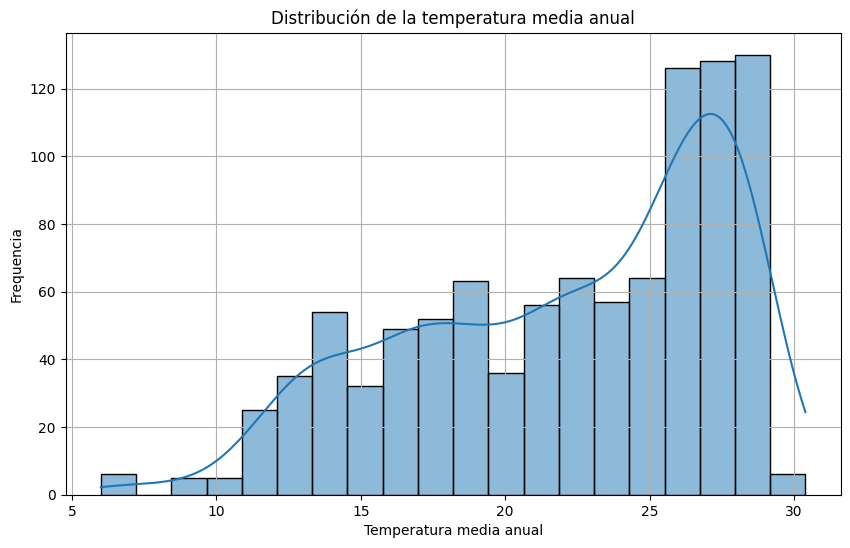

In [ ]:
df_temperatura_media = df_copia[df_copia["PARAMETRO"] == "TEMPERATURA MEDIA"].copy()

plt.figure(figsize=(10, 6))
sns.histplot(df_temperatura_media["ANUAL"], bins=20, kde=True)
plt.title("Distribución de la temperatura media anual")
plt.xlabel("Temperatura media anual en grados ")
plt.ylabel("Frequencia")
plt.grid(True)
plt.show()

### Corrección de Valores de Precipitación Negativos

Como se identificó en el resumen, los valores negativos para la precipitación en algunos meses son anómalos, ya que la precipitación no puede ser menor a cero. A continuación, corregiremos estos valores, estableciéndolos en cero.

In [ ]:
# Columnas mensuales donde se espera precipitación
colum_men_precipitacion = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']

# Filtrar el DataFrame para el parámetro de "PRECIPITACIÓN"
df_precipitacion_raw = df_copia[df_copia['PARAMETRO'] == 'PRECIPITACIÓN'].copy()

# Iterar sobre las columnas mensuales y reemplazar valores negativos con 0
for col in colum_men_precipitacion:
    df_precipitacion_raw.loc[df_precipitacion_raw[col] < 0, col] = 0

# Verificar si aún hay valores negativos en las columnas de precipitación
val_negativo = df_precipitacion_raw[colum_men_precipitacion].min()
print("Valores mínimos de precipitación después de la corrección:")
print(val_negativo[val_negativo < 0])

# Actualizar el DataFrame df_copia con los valores corregidos
df_copia.loc[df_copia['PARAMETRO'] == 'PRECIPITACIÓN', colum_men_precipitacion] = df_precipitacion_raw[colum_men_precipitacion]

print("\nSe han corregido los valores negativos de precipitación a cero.")

Valores mínimos de precipitación después de la corrección:
Series([], dtype: float64)

Se han corregido los valores negativos de precipitación a cero.


In [ ]:
!pip install geopandas matplotlib

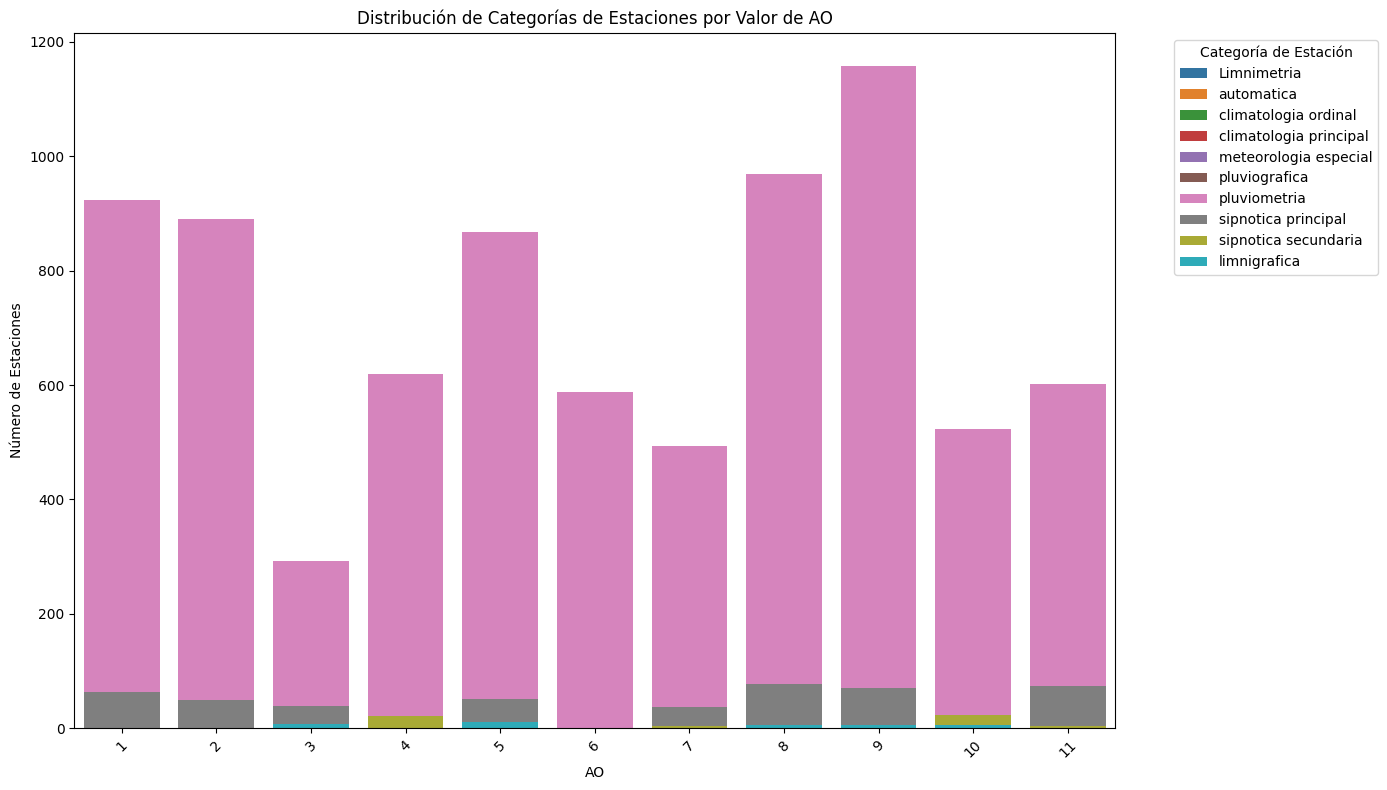

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la ocurrencia de cada CATEGORIA para cada AO
df_counts = df_copia.groupby(['AO', 'CATEGORIA']).size().reset_index(name='count')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_counts, x='AO', y='count', hue='CATEGORIA', dodge=False)
plt.title('Distribución de Categorías de Estaciones por Valor de AO')
plt.xlabel('AO')
plt.ylabel('Número de Estaciones')
plt.xticks(rotation=45)
plt.legend(title='Categoría de Estación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Evolución de Categorías de Estaciones por 'AO' (Gráfico de Líneas)

Para visualizar cómo cambia el número de estaciones de cada 'CATEGORIA' a medida que el valor de 'AO' evoluciona, crearemos un gráfico de líneas. Cada línea representará una 'CATEGORIA' diferente, mostrando su tendencia a través de los valores de 'AO'.

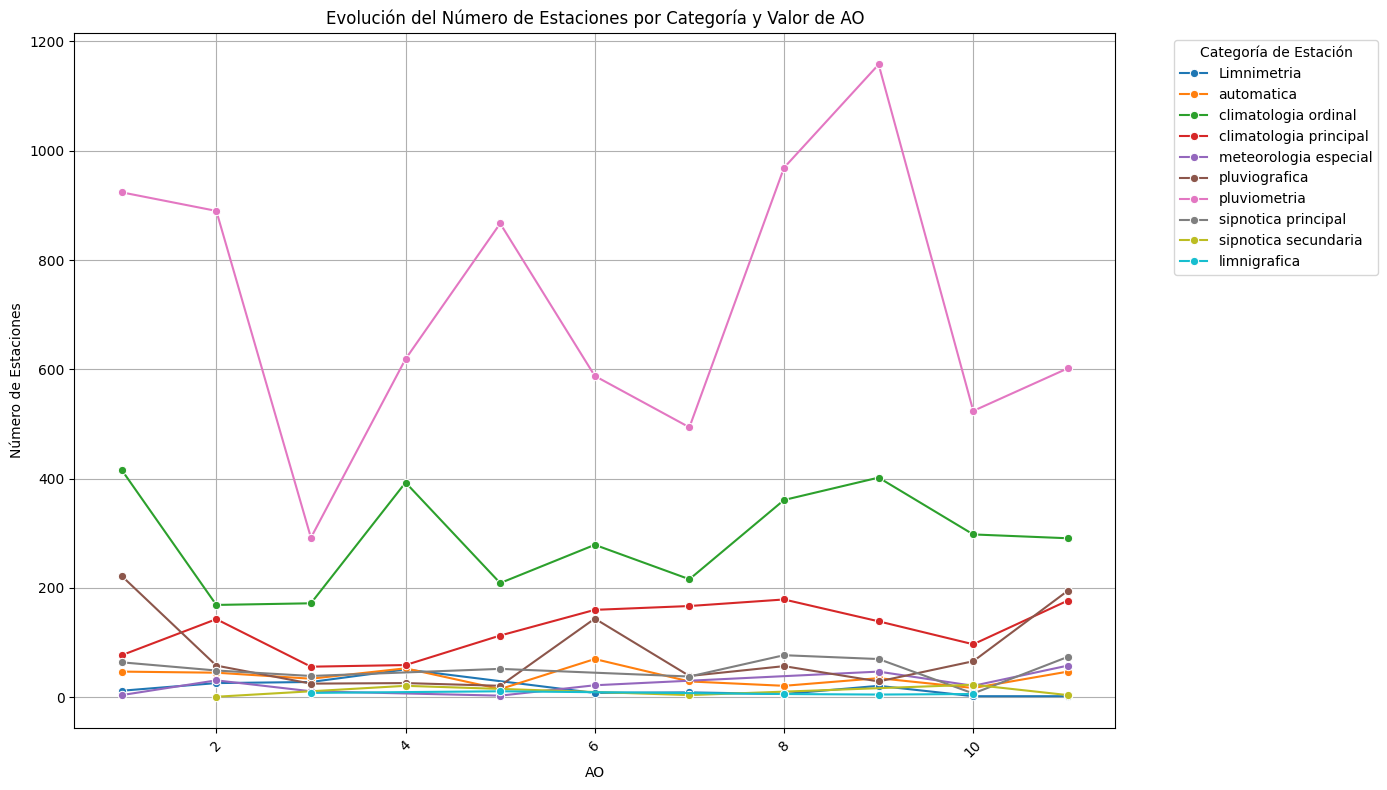

In [ ]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_counts, x='AO', y='count', hue='CATEGORIA', marker='o')
plt.title('Evolución del Número de Estaciones por Categoría y Valor de AO')
plt.xlabel('AO')
plt.ylabel('Número de Estaciones')
plt.xticks(rotation=45)
plt.legend(title='Categoría de Estación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Archivo GeoJSON cargado exitosamente.
Columnas disponibles en el GeoDataFrame: ['DPTO', 'NOMBRE_DPT', 'AREA', 'PERIMETER', 'HECTARES', 'geometry']


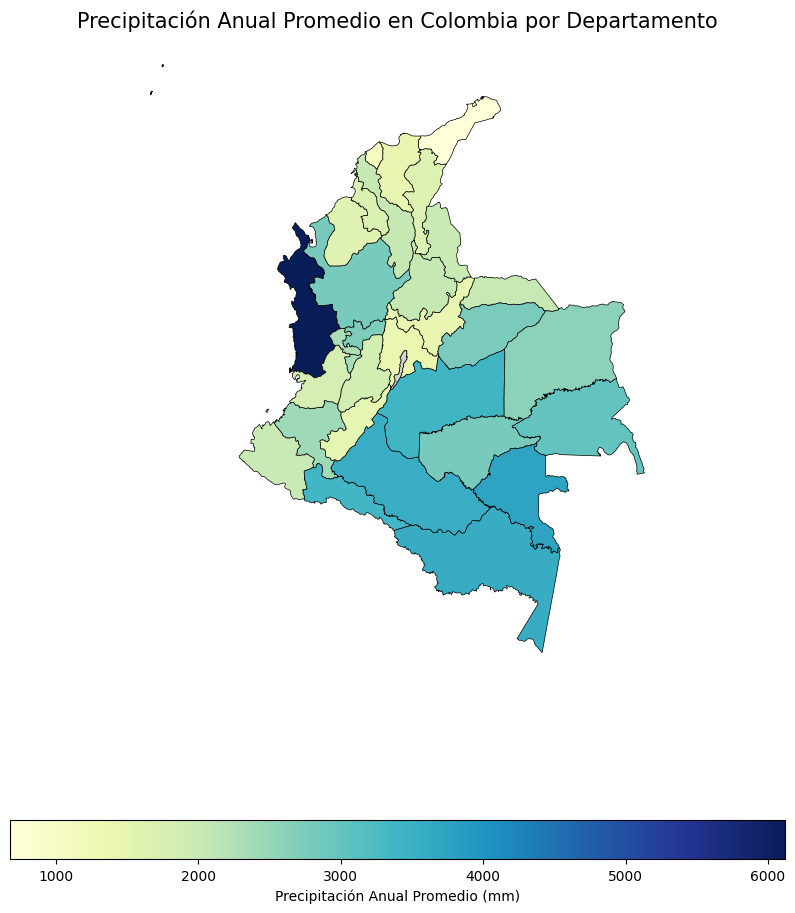

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://gist.githubusercontent.com/john-guerra/43c7656821069d00dcbc/raw/be6a6e239cd5b5b803c6e7c2ec405b793a9064dd/Colombia.geo.json"
gdf_colombia = gpd.read_file(url)

if not gdf_colombia.empty:
    print("Archivo GeoJSON cargado exitosamente.")
    print("Columnas disponibles en el GeoDataFrame:", gdf_colombia.columns.tolist())

    # El archivo Colombia.geo.json de john-guerra suele usar 'NOMBRE_DPT' o 'DPTO_CNMBRE'.
    # Adaptamos la lógica para manejar esta columna específica o las posibles alternativas.
    if 'NOMBRE_DPT' in gdf_colombia.columns:
        pass # Ya tiene el nombre correcto
    elif 'DPTO_CNMBRE' in gdf_colombia.columns:
        gdf_colombia = gdf_colombia.rename(columns={'DPTO_CNMBRE': 'NOMBRE_DPT'})
    elif 'name' in gdf_colombia.columns:
        gdf_colombia = gdf_colombia.rename(columns={'name': 'NOMBRE_DPT'})
    elif 'departamen' in gdf_colombia.columns:
        gdf_colombia = gdf_colombia.rename(columns={'departamen': 'NOMBRE_DPT'})
    elif 'DPTO' in gdf_colombia.columns:
        gdf_colombia = gdf_colombia.rename(columns={'DPTO': 'NOMBRE_DPT'})
    else:
        print("No se encontró una columna de nombre de departamento compatible en el GeoDataFrame. No se puede continuar con la unión para el mapa.")
        gdf_colombia = gpd.GeoDataFrame() # Hacerlo vacío para saltar la generación del mapa

    # Normalización para que coincida con tus datos de precipitación
    if 'NOMBRE_DPT' in gdf_colombia.columns:
        gdf_colombia['NOMBRE_DPT'] = (gdf_colombia['NOMBRE_DPT']
                                      .str.normalize('NFKD')
                                      .str.encode('ascii', errors='ignore')
                                      .str.decode('utf-8')
                                      .str.upper())
    else:
        print("La columna 'NOMBRE_DPT' no se creó correctamente. No se puede continuar con la unión para el mapa.")
        gdf_colombia = gpd.GeoDataFrame()


# --- El resto de tu lógica de unión (merge) y graficado --- #
if not gdf_colombia.empty:
    # Asumiendo que df_copia ya existe en tu entorno:
    df_precipitacion = df_copia[df_copia['PARAMETRO'] == 'PRECIPITACIÓN'].copy()
    df_precipitacion['DEPARTAMENTO_NORMALIZADO'] = (df_precipitacion['DEPARTAMENTO']
                                                    .str.normalize('NFKD')
                                                    .str.encode('ascii', errors='ignore')
                                                    .str.decode('utf-8')
                                                    .str.upper())

    departamento_precipitacion_anual = df_precipitacion.groupby('DEPARTAMENTO_NORMALIZADO')['ANUAL'].mean().reset_index()
    departamento_precipitacion_anual = departamento_precipitacion_anual.rename(
        columns={'DEPARTAMENTO_NORMALIZADO': 'NOMBRE_DPT', 'ANUAL': 'PRECIPITACION_ANUAL_PROMEDIO'}
    )

    gdf_merged = gdf_colombia.merge(departamento_precipitacion_anual, on='NOMBRE_DPT', how='left')

    # Graficar
    fig, ax = plt.subplots(1, 1, figsize=(10, 12))
    gdf_merged.plot(
        column='PRECIPITACION_ANUAL_PROMEDIO',
        ax=ax,
        legend=True,
        cmap='YlGnBu',
        edgecolor='black',
        linewidth=0.5,
        missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
        legend_kwds={'label': "Precipitación Anual Promedio (mm)", 'orientation': 'horizontal'}
    )

    ax.set_title('Precipitación Anual Promedio en Colombia por Departamento', fontsize=15)
    ax.set_axis_off()
    plt.show()
else:
    print("No se pudo cargar o preparar el GeoJSON, no se generará el mapa.")